In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#**DATA LOADING & SCHEMA RESET**

The dataset is clean with no missing values.

Renaming columns ensures compatibility with mathematical notations in the paper.

In [6]:
df = pd.read_excel('Concrete_Data.xls')

# Shorten names for technical consistency and easier coding
# Units: kg in a m^3 mixture, Age in days, Strength in MPa
df.columns = ['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplasticizer',
              'CoarseAgg', 'FineAgg', 'Age', 'Strength']

print("--- Data Sample ---")
print(df.head())

--- Data Sample ---
   Cement   Slag  FlyAsh  Water  Superplasticizer  CoarseAgg  FineAgg  Age  \
0   540.0    0.0     0.0  162.0               2.5     1040.0    676.0   28   
1   540.0    0.0     0.0  162.0               2.5     1055.0    676.0   28   
2   332.5  142.5     0.0  228.0               0.0      932.0    594.0  270   
3   332.5  142.5     0.0  228.0               0.0      932.0    594.0  365   
4   198.6  132.4     0.0  192.0               0.0      978.4    825.5  360   

    Strength  
0  79.986111  
1  61.887366  
2  40.269535  
3  41.052780  
4  44.296075  


#**INTEGRITY & NULL-VALUE CHECK**

In [7]:
print("\n--- Integrity Check ---")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")


--- Integrity Check ---
Total Rows: 1030 | Total Columns: 9


**Check Null Value**

In [8]:
null_counts = df.isnull().sum()
print("\nMissing values per column:\n", null_counts)


Missing values per column:
 Cement              0
Slag                0
FlyAsh              0
Water               0
Superplasticizer    0
CoarseAgg           0
FineAgg             0
Age                 0
Strength            0
dtype: int64


**Check Duplicate**

In [9]:
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 25


**Handling duplicates to prevent model bias**

In [10]:
if duplicates > 0:
    df = df.drop_duplicates()
    print("Action: Duplicate rows have been removed.")

Action: Duplicate rows have been removed.


The dataset is verified for completeness.

Removing duplicates ensures the model doesn't overfit on repeated experimental trials.

#**STATISTICAL ANALYSIS & OUTLIERS**

In [11]:
print("\n--- Statistical Summary ---")
summary = df.describe()
print(summary)


--- Statistical Summary ---
            Cement         Slag       FlyAsh        Water  Superplasticizer  \
count  1005.000000  1005.000000  1005.000000  1005.000000       1005.000000   
mean    278.629055    72.043134    55.535075   182.074378          6.031647   
std     104.345003    86.170555    64.207448    21.340740          5.919559   
min     102.000000     0.000000     0.000000   121.750000          0.000000   
25%     190.680000     0.000000     0.000000   166.610000          0.000000   
50%     265.000000    20.000000     0.000000   185.700000          6.100000   
75%     349.000000   142.500000   118.270000   192.940000         10.000000   
max     540.000000   359.400000   200.100000   247.000000         32.200000   

         CoarseAgg      FineAgg          Age     Strength  
count  1005.000000  1005.000000  1005.000000  1005.000000  
mean    974.376468   772.686617    45.856716    35.250273  
std      77.579534    80.339851    63.734692    16.284808  
min     801.000000 

**Visualize Outliers using Boxplots**

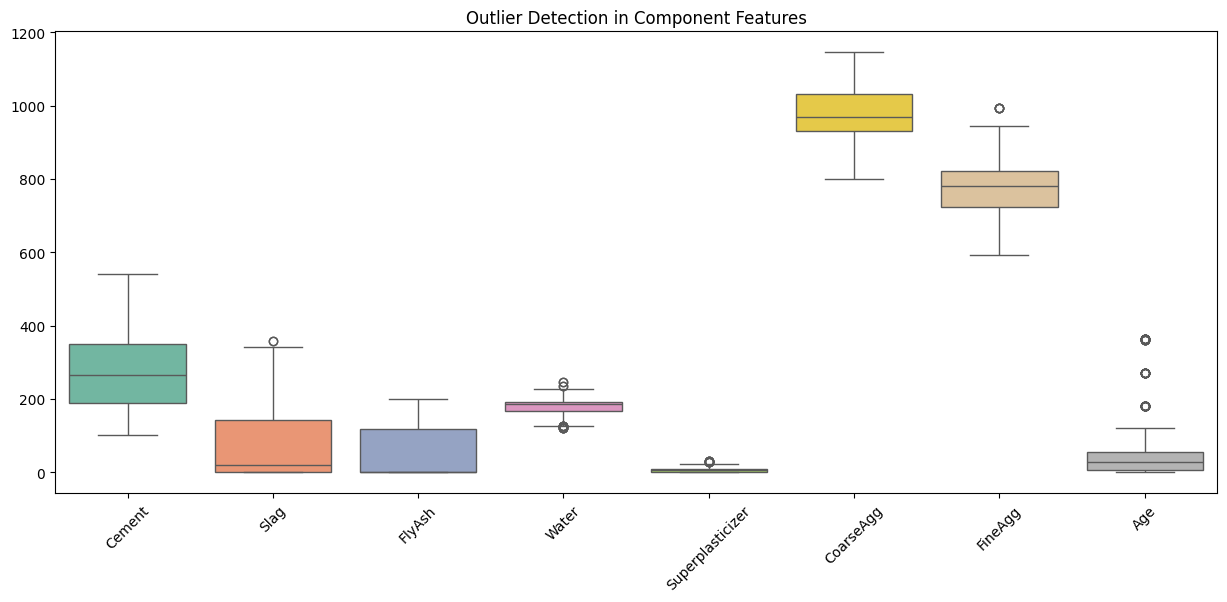

In [12]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df.drop('Strength', axis=1), palette="Set2")
plt.title("Outlier Detection in Component Features")
plt.xticks(rotation=45)
plt.show()

 'Age' and 'Superplasticizer' show several outliers.

In concrete science, 'Age' values of 365 days are rare but valid (long-term strength).

We will keep them but use robust scaling later.

#**VISUAL EDA & TARGET ANALYSIS**

In [13]:
plt.figure(figsize=(18, 10))

<Figure size 1800x1000 with 0 Axes>

<Figure size 1800x1000 with 0 Axes>

**Distribution of the Target variable (Strength)**

Text(0.5, 1.0, 'Concrete Compressive Strength Distribution')

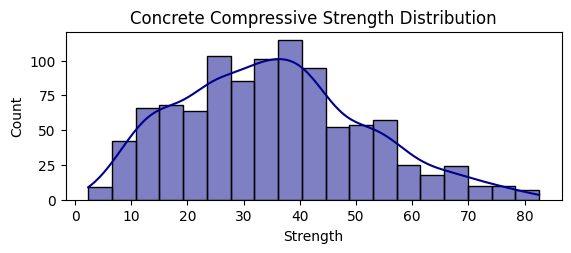

In [14]:
plt.subplot(2, 1, 1)
sns.histplot(df['Strength'], kde=True, color='darkblue')
plt.title('Concrete Compressive Strength Distribution')

**Correlation Heatmap**

'Cement' has the highest positive correlation with 'Strength'.

Text(0.5, 1.0, 'Feature Correlation Matrix')

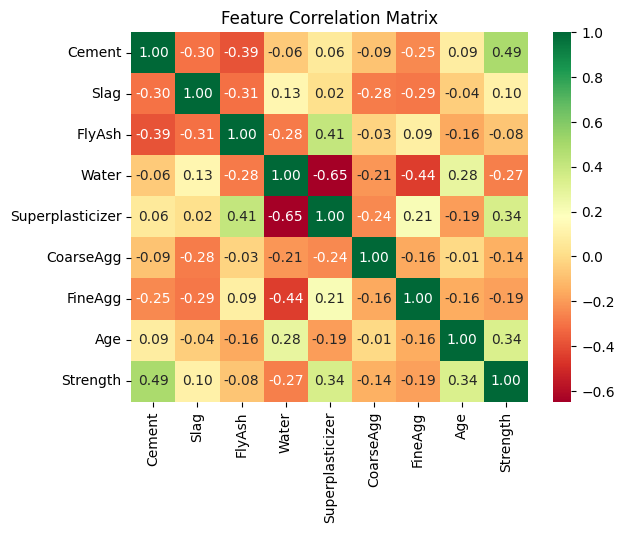

In [15]:
plt.subplot(1, 1, 1)
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Feature Correlation Matrix')

**Age vs Strength**

'Age' shows a logarithmic growth pattern, not a straight line.

Text(0.5, 1.0, 'Non-linear Relationship: Age vs Strength')

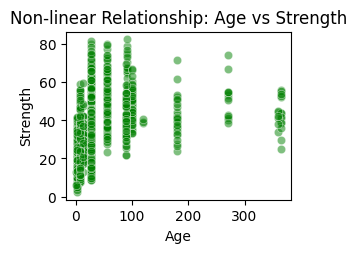

In [16]:
plt.subplot(2, 2, 2)
sns.scatterplot(x='Age', y='Strength', data=df, alpha=0.5, color='green')
plt.title('Non-linear Relationship: Age vs Strength')

**Water vs Strength**

'Water' content negatively impacts strength, confirming civil engineering theory.

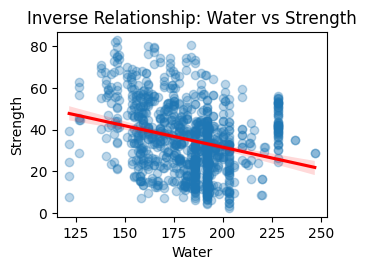

In [17]:
plt.subplot(2, 2, 4)
sns.regplot(x='Water', y='Strength', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Inverse Relationship: Water vs Strength')

plt.tight_layout()
plt.show()

#**DATA EXPORT**

In [18]:
df.to_csv('concrete_cleaned.csv', index=False)